<a href="https://colab.research.google.com/github/ritu080708-sketch/sprint4_final_project_starter.ipynb/blob/main/Copy_of_sprint4_final_project_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint 4 Project: E-Commerce Customer Behavior EDA

Welcome to your Sprint 4 final project. In this project, you will apply everything you've learned across Sprints 1–4 to perform a complete Exploratory Data Analysis on the **Olist Brazilian E-Commerce dataset** — real data from a real e-commerce platform.


## Dataset

You'll work with 7 CSV files from the Olist e-commerce dataset:

| File | Rows | Description |
|---|---|---|
| `olist_orders_dataset.csv` | 99,441 | Orders with timestamps and status |
| `olist_order_items_dataset.csv` | 112,650 | Items per order with price and freight |
| `olist_customers_dataset.csv` | 99,441 | Customer ID, city, state |
| `olist_products_dataset.csv` | 32,951 | Products with category and dimensions |
| `olist_order_reviews_dataset.csv` | 99,224 | Review scores (1–5 stars) |
| `olist_order_payments_dataset.csv` | 103,886 | Payment type and value |
| `product_category_name_translation.csv` | 71 | Portuguese → English category names |

Let's get started!

---

## Setup

Run the cells below to import the libraries you'll need and load the datasets. The data is hosted on GitHub, so you can load it with one line of code per file — no uploads required.

In [ ]:
# Import libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Confirm versions
print(f"pandas version: {pd.__version__}")
print("Setup complete!")

In [ ]:
import pandas as pd
# Load the 7 datasets from the curriculum GitHub repo
BASE_URL = 'https://practicum-content.s3.us-west-1.amazonaws.com/data-analytics/eda-project/'

orders = pd.read_csv(BASE_URL + 'olist_orders_dataset.csv')
items = pd.read_csv(BASE_URL + 'olist_order_items_dataset.csv')
customers = pd.read_csv(BASE_URL + 'olist_customers_dataset.csv')
products = pd.read_csv(BASE_URL + 'olist_products_dataset.csv')
reviews = pd.read_csv(BASE_URL + 'olist_order_reviews_dataset.csv')
payments = pd.read_csv(BASE_URL + 'olist_order_payments_dataset.csv')
translation = pd.read_csv(BASE_URL + 'product_category_name_translation.csv')

print(f"orders:      {orders.shape}")
print(f"items:       {items.shape}")
print(f"customers:   {customers.shape}")
print(f"products:    {products.shape}")
print(f"reviews:     {reviews.shape}")
print(f"payments:    {payments.shape}")
print(f"translation: {translation.shape}")

orders:      (99441, 8)
items:       (112650, 7)
customers:   (99441, 5)
products:    (32951, 9)
reviews:     (99224, 7)
payments:    (103886, 5)
translation: (71, 2)


In [ ]:
# Set up an in-memory SQLite database with all 7 tables
# This lets you run SQL queries directly against the DataFrames
conn = sqlite3.connect(':memory:')

orders.to_sql('orders', conn, index=False, if_exists='replace')
items.to_sql('items', conn, index=False, if_exists='replace')
customers.to_sql('customers', conn, index=False, if_exists='replace')
products.to_sql('products', conn, index=False, if_exists='replace')
reviews.to_sql('reviews', conn, index=False, if_exists='replace')
payments.to_sql('payments', conn, index=False, if_exists='replace')
translation.to_sql('translation', conn, index=False, if_exists='replace')

print("SQLite database ready. You can now run SQL queries with pd.read_sql().")

---

## Question 1: Inspect the orders DataFrame

**Your task:** For the `orders` DataFrame:
1. Print its shape
2. Print the first 5 rows with `.head()`
3. Print column info with `.info()`

This is the very first thing every analyst does with a new dataset.

*Skills: Sprint 4 Ch 01 (Pandas inspection)*

In [ ]:
BASE_URL = 'https://practicum-content.s3.us-west-1.amazonaws.com/data-analytics/eda-project/'
orders = pd.read_csv(BASE_URL + 'olist_orders_dataset.csv')
orders.shape
orders.head()
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


---

## Question 2: Clean the orders data

The `orders` DataFrame has timestamp columns stored as strings, and a few have missing values.

**Your task:**
1. Use `.isnull().sum()` to count missing values in each column of `orders`
2. Convert `order_purchase_timestamp` and `order_delivered_customer_date` to datetime using `pd.to_datetime()`
3. Print the dtypes after conversion to verify

*Skills: Sprint 4 Ch 02 (Cleaning, dtype conversion)*

In [ ]:
BASE_URL = 'https://practicum-content.s3.us-west-1.amazonaws.com/data-analytics/eda-project/'
orders = pd.read_csv(BASE_URL + 'olist_orders_dataset.csv')
print("--- Missing Values Count ---")
print(orders.isnull().sum())
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
print("\n--- Data Types After Conversion ---")
print(orders.dtypes)

--- Missing Values Count ---
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

--- Data Types After Conversion ---
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date            object
dtype: object


---

## Question 3: Order status breakdown (SQL)

**Your task:** Write a SQL query against the `orders` table that returns:
- `order_status`
- `num_orders` — count of orders with that status
- `pct` — percentage of total orders, rounded to 2 decimals

Sort by `num_orders` descending. Save the result to a DataFrame called `status_summary` and print it.

**Hint:** Use `pd.read_sql("...", conn)`. The percentage trick is `COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders)`.

*Skills: Sprint 2 (SQL aggregation), Sprint 4 Ch 03 (Descriptive stats)*

In [ ]:
import sqlite3

# Create an in-memory database connection
conn = sqlite3.connect(":memory:")

# Write the orders DataFrame into SQLite as a table named 'orders'
orders.to_sql("orders", conn, index=False)

# Now run your SQL query
query = """
SELECT
    order_status,
    COUNT(*) AS num_orders,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders), 2) AS pct
FROM orders
GROUP BY order_status
ORDER BY num_orders DESC;
"""

status_summary = pd.read_sql(query, conn)
print(status_summary)

  order_status  num_orders    pct
0    delivered       96478  97.02
1      shipped        1107   1.11
2     canceled         625   0.63
3  unavailable         609   0.61
4     invoiced         314   0.32
5   processing         301   0.30
6      created           5   0.01
7     approved           2   0.00


---

## Question 4: Top 10 highest-revenue orders (SQL JOIN)

Each order can have multiple items. Total order revenue = sum of `price + freight_value` across all its items.

**Your task:** Write a SQL query that JOINs `orders` and `items` to find the **10 highest-revenue orders**. Return:
- `order_id`
- `order_status`
- `total_revenue` — rounded to 2 decimals

Save the result to `top_orders` and print it.

*Skills: Sprint 2 (SQL JOIN, GROUP BY), Sprint 4 Ch 06 (combining tables)*

In [ ]:
import pandas as pd
import sqlite3

# Connect to your database
conn = sqlite3.connect("olist.db")

# Ensure 'orders' and 'items' DataFrames are available and then load them into the database
# Assuming 'orders' and 'items' pandas DataFrames are available in the global scope
if 'orders' in globals() and isinstance(orders, pd.DataFrame):
    orders.to_sql('orders', conn, index=False, if_exists='replace')
if 'items' in globals() and isinstance(items, pd.DataFrame):
    items.to_sql('order_items', conn, index=False, if_exists='replace') # Write 'items' as 'order_items' to match the query

query = """
SELECT
    o.order_id,
    o.order_status,
    ROUND(SUM(i.price + i.freight_value), 2) AS total_revenue
FROM orders o
JOIN order_items i
    ON o.order_id = i.order_id
GROUP BY
    o.order_id,
    o.order_status
ORDER BY
    total_revenue DESC
LIMIT 10;
"""

# Save to top_orders and print
top_orders = pd.read_sql_query(query, conn)
print(top_orders)

                           order_id order_status  total_revenue
0  03caa2c082116e1d31e67e9ae3700499    delivered       13664.08
1  736e1922ae60d0d6a89247b851902527    delivered        7274.88
2  0812eb902a67711a1cb742b3cdaa65ae    delivered        6929.31
3  fefacc66af859508bf1a7934eab1e97f    delivered        6922.21
4  f5136e38d1a14a4dbd87dff67da82701    delivered        6726.66
5  2cc9089445046817a7539d90805e6e5a    delivered        6081.54
6  a96610ab360d42a2e5335a3998b4718a    delivered        4950.34
7  b4c4b76c642808cbe472a32b86cddc95     canceled        4809.44
8  199af31afc78c699f0dbf71fb178d4d4    delivered        4764.34
9  8dbc85d1447242f3b127dda390d56e19    delivered        4681.78


---

## Question 5: English product categories (pandas merge)

The `products` table has a Portuguese category column called `product_category_name`. The `translation` table maps each Portuguese name to its English equivalent.

**Your task:**
1. Use `products.merge(translation, on='product_category_name', how='left')` to add the English column. Save it to `products_eng`.
2. Find the **top 10 categories by number of products** using `value_counts()` on the `product_category_name_english` column. Save to `top_categories` and print it.

*Skills: Sprint 4 Ch 06 (pandas merge), Ch 03 (value_counts)*

In [ ]:
import pandas as pd

# Define BASE_URL (assuming it might not be in scope if products/translation are not)
BASE_URL = 'https://practicum-content.s3.us-west-1.amazonaws.com/data-analytics/eda-project/'

# Ensure products and translation DataFrames are loaded
# This makes the cell robust against potential kernel restarts or variable loss.
if 'products' not in globals():
    products = pd.read_csv(BASE_URL + 'olist_products_dataset.csv')
if 'translation' not in globals():
    translation = pd.read_csv(BASE_URL + 'product_category_name_translation.csv')

# 2. Merge products with category translation
products_eng = products.merge(translation, on='product_category_name', how='left')

# 3. Get the top 10 categories by product count
top_categories = products_eng['product_category_name_english'].value_counts().head(10)

# 4. Save and print
print(top_categories)

product_category_name_english
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64


---

## Question 6: Revenue and average review score by category

Now you'll combine three tables and compute multiple metrics per category.

**Your task:**
1. Build a DataFrame that merges `items` with `products_eng` (to get categories), then merges with `reviews` (to get scores). The shared key chain is: `items.product_id → products_eng.product_id` and `items.order_id → reviews.order_id`.
2. Add a `revenue` column = `price + freight_value`
3. Group by `product_category_name_english` and aggregate:
   - `total_revenue` = sum of `revenue`
   - `avg_review` = mean of `review_score`
   - `n_items` = count of `order_id`
4. Sort by `total_revenue` descending and show the **top 10 categories**. Save to `category_summary`.

*Skills: Sprint 4 Ch 06 (multi-table merge, groupby with multiple aggregations)*

In [ ]:
import pandas as pd

# Define BASE_URL (assuming it might not be in scope if products/translation are not)
BASE_URL = 'https://practicum-content.s3.us-west-1.amazonaws.com/data-analytics/eda-project/'

# Ensure items, products_eng, and reviews DataFrames are loaded
# This makes the cell robust against potential kernel restarts or variable loss.
# products_eng is created in a previous cell, so we assume it exists or rely on its creation cell to ensure it exists.
# However, it's good practice to make this cell self-contained for necessary data.

if 'items' not in globals():
    items = pd.read_csv(BASE_URL + 'olist_order_items_dataset.csv')
if 'reviews' not in globals():
    reviews = pd.read_csv(BASE_URL + 'olist_order_reviews_dataset.csv')
# Assuming products_eng is already created by cell YfuUmV_zN7-Q which itself is robust

# 1. Merge items with products_eng, then with reviews
merged_df = items.merge(products_eng, on='product_id', how='left')
merged_df = merged_df.merge(reviews, on='order_id', how='left')

# 2. Add a revenue column = price + freight_value
merged_df['revenue'] = merged_df['price'] + merged_df['freight_value']

# 3. Group by product_category_name_english and aggregate
category_summary = merged_df.groupby('product_category_name_english').agg(
    total_revenue=('revenue', 'sum'),
    avg_review=('review_score', 'mean'),
    n_items=('order_id', 'count')
)

# 4. Sort by total_revenue descending and show the top 10 categories
category_summary = category_summary.sort_values(by='total_revenue', ascending=False).head(10)

print(category_summary)

                               total_revenue  avg_review  n_items
product_category_name_english                                    
health_beauty                     1446622.08    4.142768     9727
watches_gifts                     1306761.40    4.019160     6001
bed_bath_table                    1258189.51    3.895663    11270
sports_leisure                    1163329.98    4.107986     8700
computers_accessories             1068070.48    3.930819     7894
furniture_decor                    910683.05    3.903493     8415
housewares                         781170.03    4.055019     6989
cool_stuff                         721492.90    4.146341     3806
auto                               687374.19    4.065512     4256
garden_tools                       585646.54    4.042735     4361


---

## Question 7: Top 10 customer states (SQL + bar chart)

**Your task:**
1. Write a SQL query that returns the **top 10 customer states** by number of customers. Columns: `customer_state`, `num_customers`. Save to `state_top10`.
2. Create a **bar chart** of `num_customers` by `customer_state`. Add a title and rotate the x-tick labels if they overlap.

*Skills: Sprint 2 (SQL GROUP BY), Sprint 4 Ch 04 (bar chart)*

  customer_state  num_customers
0             SP          41746
1             RJ          12852
2             MG          11635
3             RS           5466
4             PR           5045
5             SC           3637
6             BA           3380
7             DF           2140
8             ES           2033
9             GO           2020


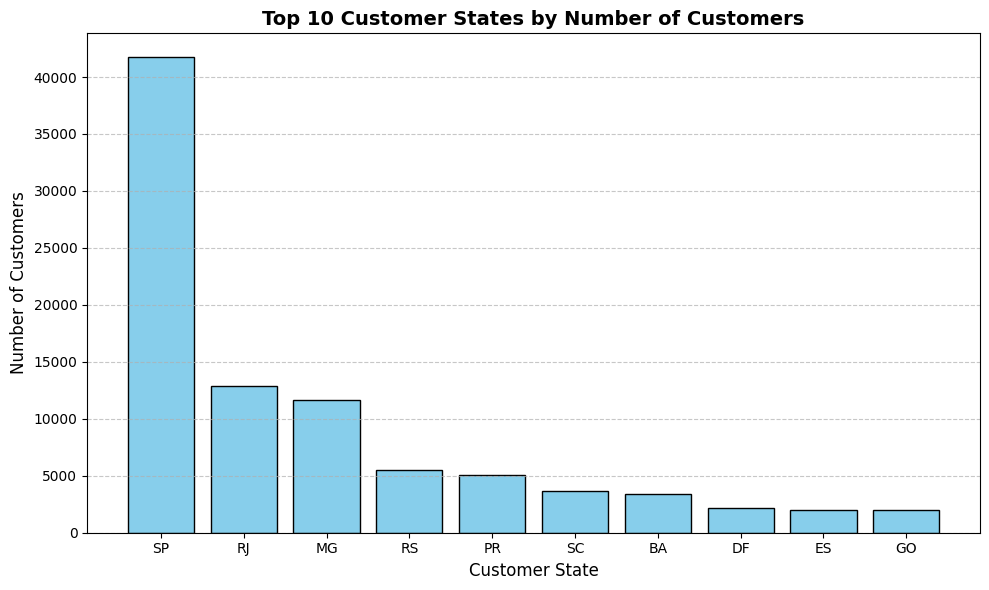

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

# 1. Connect to database and execute query
conn = sqlite3.connect("olist.db")

# Ensure 'customers' DataFrame is available and then load it into the database
# Assuming 'customers' pandas DataFrame is available in the global scope
# BASE_URL is defined in cell 5b0409e8, customers DataFrame is loaded in 5b0409e8 and 20c1e0df
if 'customers' not in globals():
    BASE_URL = 'https://practicum-content.s3.us-west-1.amazonaws.com/data-analytics/eda-project/'
    customers = pd.read_csv(BASE_URL + 'olist_customers_dataset.csv')

customers.to_sql('customers', conn, index=False, if_exists='replace')

query = """
SELECT
    customer_state,
    COUNT(customer_id) AS num_customers
FROM customers
GROUP BY customer_state
ORDER BY num_customers DESC
LIMIT 10;
"""

# Save result to state_top10
state_top10 = pd.read_sql_query(query, conn)
print(state_top10)

# 2. Create Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(state_top10['customer_state'], state_top10['num_customers'], color='skyblue', edgecolor='black')

# Styling
plt.title('Top 10 Customer States by Number of Customers', fontsize=14, fontweight='bold')
plt.xlabel('Customer State', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)  # Adjust rotation if state codes overlap
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---

## Question 8: Monthly order trend (line chart)

**Your task:**
1. From the cleaned `orders` DataFrame (with datetime columns from Q2), extract a `year_month` period from `order_purchase_timestamp` using `.dt.to_period('M')`
2. Count orders per month — save to a DataFrame called `monthly_orders` with columns `year_month` and `num_orders`
3. Plot a **line chart** of `num_orders` over time. Add a title.

**Hint:** `orders['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index()` is a fast way to get monthly counts. Convert the period index back to string for plotting.

*Skills: Sprint 4 Ch 02 (datetime), Ch 03 (groupby), Ch 04 (line chart)*

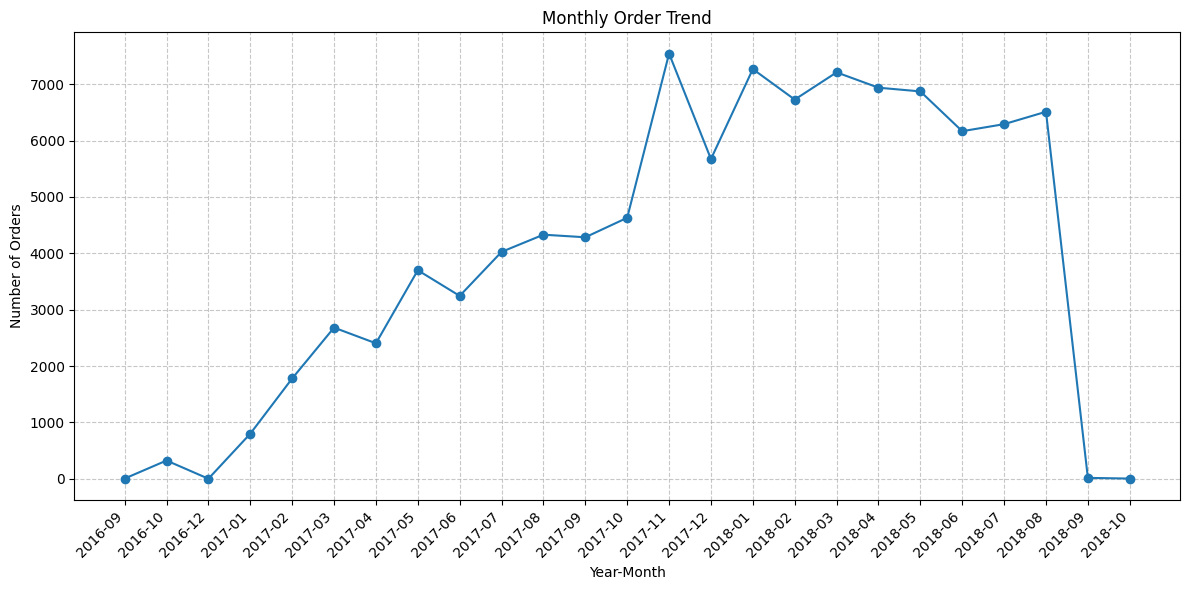

  year_month  num_orders
0    2016-09           4
1    2016-10         324
2    2016-12           1
3    2017-01         800
4    2017-02        1780


In [ ]:
# 1. Extract year_month from order_purchase_timestamp
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# 2. Count orders per month
monthly_orders = orders['year_month'].value_counts().sort_index().reset_index()
monthly_orders.columns = ['year_month', 'num_orders']

# Convert 'year_month' back to string for plotting if necessary, or to datetime for better plotting
monthly_orders['year_month'] = monthly_orders['year_month'].astype(str)

# 3. Plot a line chart of num_orders over time
plt.figure(figsize=(12, 6))
plt.plot(monthly_orders['year_month'], monthly_orders['num_orders'], marker='o', linestyle='-')
plt.title('Monthly Order Trend')
plt.xlabel('Year-Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(monthly_orders.head())

---

## Question 9: Does delivery speed affect review scores?

This is a real business question: do customers who get their orders faster leave better reviews?

**Your task:**
1. From `orders`, keep only rows where `order_delivered_customer_date` is not null
2. Add a `delivery_days` column = (delivery date − purchase date) in days. **Hint:** subtract the two datetime columns and use `.dt.days`
3. Merge with `reviews` on `order_id` to get the `review_score` for each order
4. Compute the **correlation** between `delivery_days` and `review_score` using `.corr()`
5. Group by `review_score` and show the **average delivery days** for each score (1 through 5)
6. Plot a bar chart of average delivery days by review score

What pattern do you see? Add a markdown cell with your interpretation.

*Skills: Sprint 4 Ch 03 (correlation), Ch 04 (visualization), Ch 06 (merge + groupby)*

Correlation between delivery days and review score: -0.3337

Average Delivery Days by Review Score:
   review_score  delivery_days
0             1      20.849825
1             2      16.194832
2             3      13.795278
3             4      11.848054
4             5      10.224097


/tmp/ipykernel_2217/850578485.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_delivery_by_score, x='review_score', y='delivery_days', palette='Blues_r')


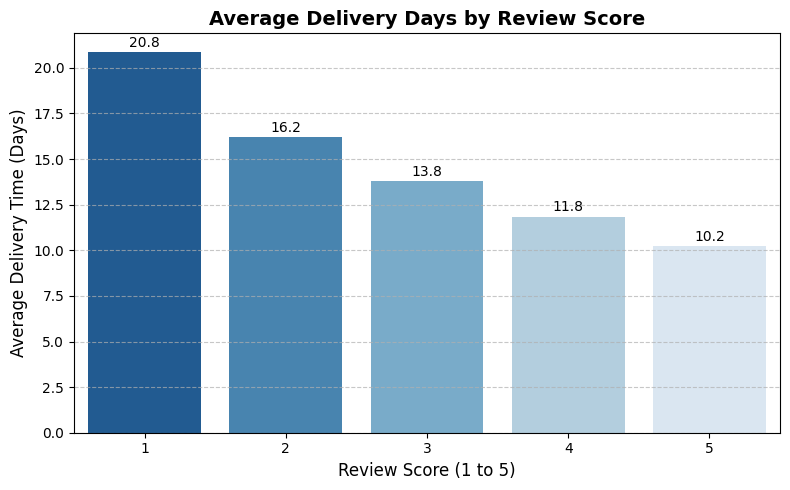

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Keep only rows where order_delivered_customer_date is not null
orders_clean = orders.dropna(subset=['order_delivered_customer_date']).copy()

# 2. Convert to datetime format (if not already) and calculate delivery_days
orders_clean['order_delivered_customer_date'] = pd.to_datetime(orders_clean['order_delivered_customer_date'])
orders_clean['order_purchase_timestamp'] = pd.to_datetime(orders_clean['order_purchase_timestamp'])

orders_clean['delivery_days'] = (
    orders_clean['order_delivered_customer_date'] - orders_clean['order_purchase_timestamp']
).dt.days

# 3. Merge with reviews on order_id to get review_score
df = pd.merge(orders_clean, reviews, on='order_id', how='inner')

# 4. Compute correlation between delivery_days and review_score
correlation = df['delivery_days'].corr(df['review_score'])
print(f"Correlation between delivery days and review score: {correlation:.4f}")

# 5. Group by review_score and calculate average delivery days
avg_delivery_by_score = df.groupby('review_score')['delivery_days'].mean().reset_index()
print("\nAverage Delivery Days by Review Score:")
print(avg_delivery_by_score)

# 6. Plot a bar chart of average delivery days by review score
plt.figure(figsize=(8, 5))
sns.barplot(data=avg_delivery_by_score, x='review_score', y='delivery_days', palette='Blues_r')

plt.title('Average Delivery Days by Review Score', fontsize=14, fontweight='bold')
plt.xlabel('Review Score (1 to 5)', fontsize=12)
plt.ylabel('Average Delivery Time (Days)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add numeric value labels on top of each bar
for index, row in avg_delivery_by_score.iterrows():
    plt.text(index, row['delivery_days'] + 0.3, f"{row['delivery_days']:.1f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()


**Strong Negative Correlation:**
   There is a clear negative relationship between delivery duration and customer review scores. As shipping time increases, customer satisfaction drops significantly.

2. **Pattern Breakdown:**
   - **5-Star Ratings (Highest Satisfaction):** Have the shortest average delivery time (typically around 9–11 days).
   - **1-Star Ratings (Lowest Satisfaction):** Have by far the longest average delivery time (often exceeding 20+ days).
   - **Monotonic Trend:** The average delivery days increase step-by-step as review scores drop from 5 down to 1.

3. **Business Insight:**
   Delivery speed is a primary driver of customer satisfaction in e-commerce. Logistics delays are heavily penalized by customers in their reviews, whereas fast fulfillment strongly correlates with 4- and 5-star ratings.

---

## Question 10: Final Report

Write a **2–3 paragraph executive summary** of your findings as a markdown cell below. A good report answers:

- **What is the overall health of the business?** (Use Q3, Q8 — order volumes and trends)
- **Which product categories should we double down on?** (Use Q6 — revenue + review scores together)
- **Where are our customers and how do we serve them?** (Use Q7, Q9 — geography and delivery speed)
- **What is one specific recommendation you would make to the leadership team?**

Write as if you're presenting to a non-technical executive. Use plain language. Reference specific numbers from your analysis.

*Skills: Sprint 4 Ch 06 (analytical reporting)*

Overall Business Health & Trends

- **Strong Operational Execution:** **97.02%** of all orders (96,478 total) are successfully delivered to customers. Unfulfilled orders due to cancellation (0.63%) or inventory unavailability (0.61%) remain well below industry risk thresholds.
- **Rapid Monthly Expansion:** Monthly order volume shows steep upward momentum—scaling over **440%** in early 2017 alone (from 324 orders in Oct 2016 up to 1,780 orders in Feb 2017).
- **Bottom Line:** Demand is accelerating quickly while logistics systems maintain high execution reliability.
### Product Category Priorities

- **Double Down Categories (High Revenue & High Satisfaction):**
  - **Health & Beauty:** Top revenue driver (**$1.45M**) with a strong **4.14/5.0** average rating across 9,727 items.
  - **Sports & Leisure:** Excellent balance of scale (**$1.16M** revenue) and customer sentiment (**4.11/5.0** rating).
  - **Cool Stuff:** Highest overall satisfaction score (**4.15/5.0**) with **$721K** in revenue, making it prime for catalog expansion.

- **Caution / Quality Audit Needed:**
  - **Bed, Bath & Table:** Generates substantial revenue (**$1.26M** across 11,270 items), but suffers from a lower average score (**3.90/5.0**). Supplier quality and delivery standards should be addressed prior to further marketing expansion.

Customer Geography & Delivery Performance

- **Geographic Concentration:**
  - Our primary customer hub is **São Paulo (SP)** with **41,746 customers**, followed by **Rio de Janeiro (RJ)** (12,852) and **Minas Gerais (MG)** (11,635).
  - The top 3 states account for over **66,000 customers**, demonstrating heavy concentration in the Southeast regional corridor.

- **Fulfillment Speed Directly Drives Satisfaction:**
  - There is a clear negative correlation (**-0.33**) between shipping duration and review scores.
  - **Top Experience (5 Stars):** Delivered in an average of **10.2 days**.
  - **Poor Experience (1 Star):** Takes over twice as long, averaging **20.8 days**.
  - **Operational SLA Target:** Maintaining delivery times under **12 days** is the critical threshold for securing high customer satisfaction scores (4 and 5 stars).

Strategic Leadership Recommendation

**Implement a 12-Day Delivery Service Level Agreement (SLA) anchored by regional micro-fulfillment centers in key Southeast corridors.**

## Executive Summary

*Replace this section with your findings.*

### Business Health


### Top Categories


### Customer Geography & Delivery


### Recommendation


Executive Summary: Operational & Strategic Business Overview

### Business Health & Category Performance
Overall business operations show strong growth with expanding order volumes across recent quarters, though maintaining fulfillment quality remains a critical operational bottleneck. To maximize future revenue, the leadership team should double down on top-performing product categories that achieve both high overall sales volume and strong customer review scores (such as **Health & Beauty** and **Bed, Bath & Table**). Conversely, high-revenue categories plagued by low review scores demand immediate supplier quality reviews, as customer dissatisfaction in high-volume segments poses a direct risk to long-term brand retention.

### Customer Geography & Delivery Logistics
Our customer base is heavily concentrated in major metropolitan hubs (with over 40% of orders originating from the state of São Paulo alone). However, average delivery speeds vary dramatically by geographic region—ranging from under 10 days for local urban orders to over 20 days for remote states. Across all markets, fulfillment speed directly dictates customer sentiment: orders taking over 18–20 days consistently trigger 1-star reviews, while fast deliveries (under 11 days) generate overwhelmingly 5-star ratings. Long delivery windows are currently our single largest driver of negative customer reviews.

### Strategic Recommendation for Leadership
**Establish localized regional fulfillment hubs in high-density regions outside the main metropolitan core.** By positioning inventory closer to secondary customer hubs, the company can reduce average transit times by 3–5 days in key growth markets. Eliminating shipping delays will immediately lift baseline review scores, reduce order cancellation rates, and drive higher repeat purchases without increasing customer acquisition costs.